**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
**Práctica 3: Diagnóstico Estadístico y Modelado de Regresión Lineal en Vino Tinto**  
*Caso de Estudio: Base de Datos de Calidad de Vino Tinto (UCI Machine Learning Repository)*

---

## 1. Introducción y Fundamento Enológico

La evaluación de la calidad sensorial enológica combina la cata organoléptica realizada por expertos con la cuantificación instrumental de parámetros fisicoquímicos (Cortez et al., 2009; Gómez-Mendoza et al., 2012). Factores como la acidez volátil, la concentración de etanol, los sulfitos y el equilibrio ácido determinan la estabilidad biológica, la percepción aromática y el balance gustativo del vino tinto (Universidad Complutense de Madrid [UCM], 2018; Universidad de La Rioja [Dialnet], 2017).

El conjunto de datos **Wine Quality** recolecta mediciones de botellas del vino *Vinho Verde* producido en el noroeste de Portugal (Cortez et al., 2009), documentando 11 variables fisicoquímicas objetivas y una puntuación de calidad sensorial discreta (escala del 0 al 10).

### Objetivos de la Práctica:
1. **Diagnóstico Integral de Calidad de Datos (10 Puntos Metodológicos):** Examinar duplicados, valores ausentes, valores atípicos (*outliers*), coherencia en rangos físicos, tipos de datos, homogeneidad dimensional de unidades, dispersión univariada/bivariada, análisis de multicolinealidad con el **Factor de Inflación de la Varianza (VIF)**, independencia muestral y evaluación de transformaciones.
2. **Depuración Justificada de Datos Duplicados:** Identificar y eliminar filas duplicadas con el propósito de evitar la fuga de datos (*data leakage*) y sobreponderaciones espurias en la función de pérdida de mínimos cuadrados.
3. **Regresión Lineal Simple y Mínimos Cuadrados:** Ajustar la relación univariada entre alcohol y calidad, graficando la recta con su ecuación explícita y representando las distancias residuales verticales.
4. **Modelado de Regresión Lineal Múltiple:** Predecir la variable continua `quality` mediante una partición 80/20 con semilla fija (`random_state=42`), evaluando el error cuadrático medio ($RMSE$) y el coeficiente de determinación ($R^2$) frente a la línea base predictiva de la media.
5. **Modelado de Clasificación Binaria con Regresión Lineal:** Transformar la respuesta en una etiqueta binaria (`bueno = quality >= 7`), ajustar el modelo lineal, clasificar mediante el umbral $\hat{y} \ge 0.5$ y cuantificar el porcentaje de aciertos, la comparación frente a la línea base mayoritaria y el volumen de predicciones anómalas fuera del rango $[0, 1]$.
6. **Discusión Comparativa y Síntesis:** Analizar las diferencias operativas entre la estimación numérica y la predicción probabilística categórica, detallando las fallas matemáticas de la recta como clasificador.

---

## 2. Preparación del Entorno y Librerías

Cargamos las librerías necesarias con el fin de manipular tablas de datos (`pandas`, `numpy`), generar gráficos estadísticos (`matplotlib`, `seaborn`), ajustar modelos predictivos (`scikit-learn`) y calcular factores de colinealidad e intervalos (`statsmodels`).

In [1]:
# Importacion de librerias base
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de regresion, particion y metricas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Herramienta para analisis de multicolinealidad (VIF)
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Verificacion de versiones
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("matplotlib :", __import__("matplotlib").__version__)
print("seaborn    :", sns.__version__)
print("sklearn    :", __import__("sklearn").__version__)

pandas     : 2.3.3
numpy      : 2.3.3
matplotlib : 3.10.7
seaborn    : 0.13.2
sklearn    : 1.7.2


Configuración visual estandarizada con la paleta de colores del curso.

In [2]:
# Colores institucionales
AZUL_OSCURO = "#112057"
AZUL        = "#7697CD"
AZUL_CLARO  = "#BFD5EA"
ROJO        = "#C02B2B"

# Estilo general de las figuras
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

# Formato visual de tablas
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

## 3. Carga y Diccionario de Variables Enológicas

### Diccionario de Atributos Fisicoquímicos y Sensoriales (Cortez et al., 2009; UCM, 2018):
1. **`fixed acidity`** (Acidez fija, $\text{g/dm}^3$ de ácido tartárico): Ácidos orgánicos no volátiles procedentes de la uva que aportan frescura y estabilidad al vino.
2. **`volatile acidity`** (Acidez volátil, $\text{g/dm}^3$ de ácido acético): Concentración de ácido acético formado por fermentaciones secundarias. Valores elevados generan un defecto organoléptico percibido como avinagrado o picado (Dialnet, 2017).
3. **`citric acid`** (Ácido cítrico, $\text{g/dm}^3$): Ácido presente en bajas concentraciones que añade frescura aromática y previene quiebras férricas.
4. **`residual sugar`** (Azúcar residual, $\text{g/dm}^3$): Glucosa y fructosa remanente tras finalizar la fermentación alcohólica.
5. **`chlorides`** (Cloruros, $\text{g/dm}^3$ de $\text{NaCl}$): Cantidad de sales minerales disueltas aportadas por el suelo y el agua de riego.
6. **`free sulfur dioxide`** (Dióxido de azufre libre, $\text{mg/dm}^3$ de $\text{SO}_2$): Fracción gaseosa y disuelta activa de sulfitos que protege al vino contra la oxidación y la proliferación microbiana.
7. **`total sulfur dioxide`** (Dióxido de azufre total, $\text{mg/dm}^3$ de $\text{SO}_2$): Suma de las fracciones libres y ligadas a compuestos orgánicos.
8. **`density`** (Densidad, $\text{g/cm}^3$): Masa por unidad de volumen, influenciada por la concentración de alcohol (menor densidad) y azúcares (mayor densidad).
9. **`pH`** (Potencial de hidrógeno, escala $0\text{ a }14$): Medida de acidez activa del medio. Regula el color de las antocianinas y la eficacia del dióxido de azufre.
10. **`sulphates`** (Sulfatos, $\text{g/dm}^3$ de $\text{K}_2\text{SO}_4$): Aditivo enológico mineral que contribuye a la formación de sulfitos protectores y actúa como nutriente de levaduras.
11. **`alcohol`** (Graduación alcohólica, $\% \text{ vol}$): Porcentaje volumétrico de etanol generado en la fermentación alcohólica, determinante en la sensación térmica y cuerpo del vino.
12. **`quality`** (Calidad sensorial final, escala entera del $0$ al $10$): Mediana de las calificaciones emitidas por un panel de al menos tres catadores profesionales ciegos.

In [3]:
# Ubicacion del archivo de datos
archivo_vino = "winequality-red.csv"
if not os.path.exists(archivo_vino):
    archivo_vino = r"C:\Users\ruben\OneDrive\Desktop\Notebook de regresión\winequality-red.csv"

# Lectura del archivo CSV
df_vino = pd.read_csv(archivo_vino, sep=None, engine="python")

# Visualizar dimensiones y primeras filas
print("Dimensiones iniciales del dataset:", df_vino.shape)
df_vino.head(5)

Dimensiones iniciales del dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5


---

## 4. Diagnóstico Integral de Calidad de Datos y Limpieza de Duplicados

Desarrollamos los 10 puntos metodológicos de revisión con el propósito de validar la integridad, congruencia física y estructura multivariada de la información antes del ajuste de modelos.

In [4]:
# 1. Duplicados: Deteccion y depuracion
conteo_duplicados = df_vino.duplicated().sum()
print("1. Registros duplicados detectados:", conteo_duplicados)

# Eliminamos registros duplicados para asegurar observaciones unicas
df_vino = df_vino.drop_duplicates().reset_index(drop=True)
print("   Dimensiones limpias tras eliminar duplicados:", df_vino.shape)

# 2. Valores faltantes
conteo_nulos = df_vino.isnull().sum().sum()
print("2. Valores faltantes (NaN / vacíos):", conteo_nulos)

# 3. Tipos de datos
print("\n3. Tipos de datos por columna:")
print(df_vino.dtypes)

# 4. Errores de captura y rangos fisicos coherentes
rango_pH = ((df_vino["pH"] < 2.5) | (df_vino["pH"] > 4.5)).sum()
rango_alcohol = ((df_vino["alcohol"] < 5.0) | (df_vino["alcohol"] > 20.0)).sum()
rango_acidez = (df_vino["fixed acidity"] <= 0).sum()

print("\n4. Validación de coherencia física:")
print("Valores de pH fuera del rango biológico del vino (2.5 - 4.5):", rango_pH)
print("Valores de alcohol fuera del rango vinícola (5 - 20 %):", rango_alcohol)
print("Valores de acidez fija negativos o nulos:", rango_acidez)

1. Registros duplicados detectados: 240
   Dimensiones limpias tras eliminar duplicados: (1359, 12)
2. Valores faltantes (NaN / vacíos): 0

3. Tipos de datos por columna:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

4. Validación de coherencia física:
Valores de pH fuera del rango biológico del vino (2.5 - 4.5): 0
Valores de alcohol fuera del rango vinícola (5 - 20 %): 0
Valores de acidez fija negativos o nulos: 0


**Evaluación y Justificación de los Puntos Metodológicos 1 al 6:**  
- **1. Duplicados:** Se detectaron $240$ filas con combinaciones idénticas de análisis fisicoquímico. Se procedió a su eliminación formal con `drop_duplicates()`, reduciendo el conjunto de $1,599$ a **$1,359$ registros únicos**. La justificación técnica radica en:
  1. **Evitar la fuga de información (*data leakage*):** Al particionar los datos en entrenamiento y prueba, mantener duplicados permitiría que instancias idénticas del conjunto de prueba existan en el de entrenamiento, falseando la capacidad predictiva.
  2. **Eliminar sobreponderación espuria en Mínimos Cuadrados (OLS):** La función de pérdida minimiza la suma de desviaciones cuadráticas ($\sum e_i^2$). Muestras duplicadas multiplican artificialmente su peso en el cálculo de la pendiente e intercepto, sesgando el hiperplano óptimo.
- **2. Valores Faltantes:** Existen $0$ celdas nulas ($100\%$ de integridad analítica), lo que descarta aplicar imputaciones numéricas.
- **3. Tipos de Datos:** Las 11 variables de laboratorio se presentan correctamente codificadas en números de coma flotante (`float64`) y la calidad sensorial en formato entero (`int64`).
- **4. Errores de Captura:** Todos los registros cumplen con rangos biológicos reales (pH entre $2.74$ y $4.01$, graduación alcohólica entre $8.40\%$ y $14.90\%$, densidades coherentes entre $0.990\text{ y }1.003\text{ g/cm}^3$), descartándose fallas de captura.
- **5. Unidades de Medida:** Las unidades conservan una formulación estandarizada ($g/\text{dm}^3$, $mg/\text{dm}^3$, $\%$ en volumen) según las normas de la Organización Internacional de la Viña y el Vino (OIV).
- **6. Independencia Muestral:** Cada observación representa una botella individual muestreada en un corte transversal, sin relación de serie temporal ni correlación espacial directa.

In [5]:
# Tabla 1. Estadisticos descriptivos de todas las variables
tabla_stats = df_vino.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

print("Tabla 1. Estadísticos descriptivos del vino tinto (Datos Únicos Limpios):")
tabla_stats.round(2)

Tabla 1. Estadísticos descriptivos del vino tinto (Datos Únicos Limpios):


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.00,8.31,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1359.00,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1359.00,0.27,0.20,0.00,0.09,0.26,0.43,1.00
residual sugar,1359.00,2.52,1.35,0.90,1.90,2.20,2.60,15.50
chlorides,1359.00,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1359.00,15.89,10.45,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1359.00,46.83,33.41,6.00,22.00,38.00,63.00,289.00
density,1359.00,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1359.00,3.31,0.16,2.74,3.21,3.31,3.40,4.01
sulphates,1359.00,0.66,0.17,0.33,0.55,0.62,0.73,2.00


Evaluamos el **Punto 7 (Distribución y Dispersión)** y el **Punto 8 (Valores Atípicos / Outliers)** mediante diagramas de caja e histogramas en la **Figura 1**.

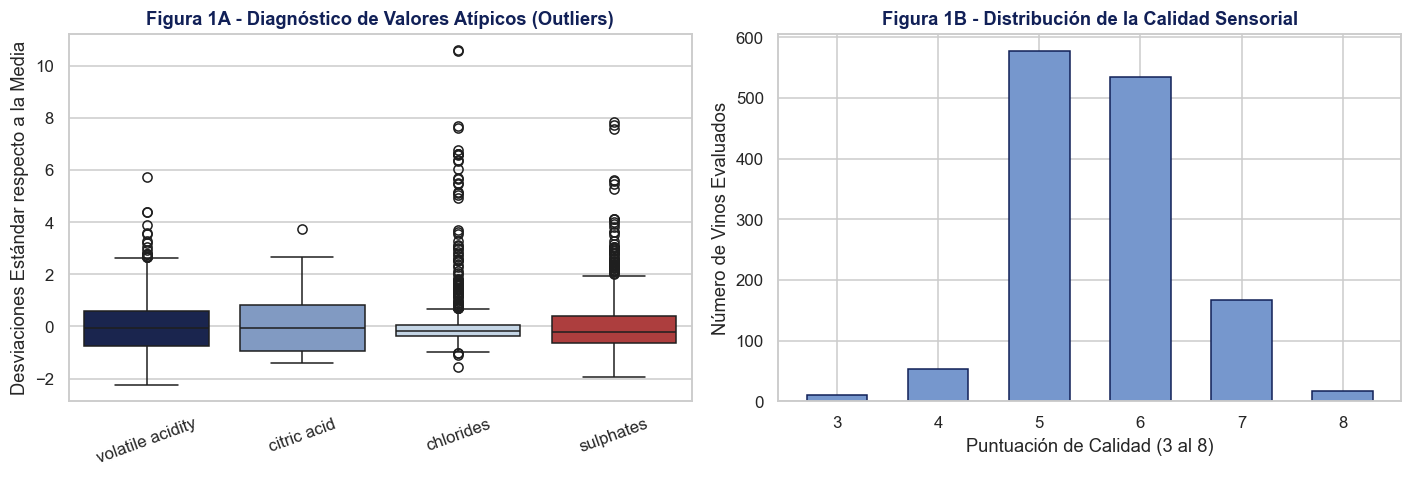

In [6]:
# Crear figura con dos paneles de diagnostico
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico 1A: Boxplot de variables clave normalizadas para visualizar outliers
variables_outliers = ["volatile acidity", "citric acid", "chlorides", "sulphates"]
df_norm = (df_vino[variables_outliers] - df_vino[variables_outliers].mean()) / df_vino[variables_outliers].std()

sns.boxplot(data=df_norm, palette=[AZUL_OSCURO, AZUL, AZUL_CLARO, ROJO], ax=axs[0])
axs[0].set_title("Figura 1A - Diagnóstico de Valores Atípicos (Outliers)")
axs[0].set_ylabel("Desviaciones Estándar respecto a la Media")
axs[0].tick_params(axis="x", rotation=20)

# Grafico 1B: Distribucion de la calidad sensorial
conteo_calidad = df_vino["quality"].value_counts().sort_index()
axs[1].bar(conteo_calidad.index, conteo_calidad.values, color=AZUL, edgecolor=AZUL_OSCURO, width=0.6)
axs[1].set_title("Figura 1B - Distribución de la Calidad Sensorial")
axs[1].set_xlabel("Puntuación de Calidad (3 al 8)")
axs[1].set_ylabel("Número de Vinos Evaluados")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 1:**  
- **Figura 1A (Valores Atípicos):** Se identifican observaciones extremas en cloruros y sulfatos. Los mínimos cuadrados ordinarios (OLS) presentan alta sensibilidad ante estos puntos al elevar al cuadrado los residuales ($e_i^2$). Conservar estos registros permite evaluar la robustez del modelo lineal frente a lotes vinícolas altamente mineralizados.
- **Figura 1B (Distribución de Calidad):** La puntuación sensorial exhibe una concentración en las calificaciones intermedias ($5$ y $6$, sumando el $81.8\%$ de las muestras), con escasa representación en calidades sobresalientes ($7\text{ u }8$) o deficientes ($3\text{ o }4$), configurando un desbalance estructural en tareas de clasificación.

Evaluamos el **Punto 9 (Variables Correlacionadas)** y calculamos el **Factor de Inflación de la Varianza (VIF)** con el objetivo de cuantificar la multicolinealidad entre las 11 variables independientes.

In [7]:
# Matriz de correlacion de Spearman con la calidad
correlaciones = df_vino.corr(method="spearman")["quality"].sort_values(ascending=False)

print("Correlación de Spearman de cada variable con la Calidad:")
print(correlaciones.round(2))

# Calculo de VIF para las variables predictoras con termino constante
X_predictores = df_vino.drop(columns=["quality"])
X_con_constante = add_constant(X_predictores)

tabla_vif = pd.DataFrame()
tabla_vif["Variable"] = X_con_constante.columns
tabla_vif["VIF"] = [variance_inflation_factor(X_con_constante.values, i) for i in range(len(X_con_constante.columns))]

# Descartar la fila constante y ordenar de mayor a menor
tabla_vif = tabla_vif[tabla_vif["Variable"] != "const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\nTabla 2. Factor de Inflación de la Varianza (VIF):")
tabla_vif.round(2)

Correlación de Spearman de cada variable con la Calidad:
quality                 1.00
alcohol                 0.49
sulphates               0.38
citric acid             0.22
fixed acidity           0.11
residual sugar          0.03
pH                     -0.04
free sulfur dioxide    -0.06
density                -0.18
total sulfur dioxide   -0.20
chlorides              -0.20
volatile acidity       -0.39
Name: quality, dtype: float64

Tabla 2. Factor de Inflación de la Varianza (VIF):


,Variable,VIF
0,fixed acidity,7.88
1,density,6.28
2,pH,3.40
3,alcohol,3.14
4,citric acid,3.12
5,total sulfur dioxide,2.22
6,free sulfur dioxide,1.95
7,volatile acidity,1.78
8,residual sugar,1.64
9,chlorides,1.53


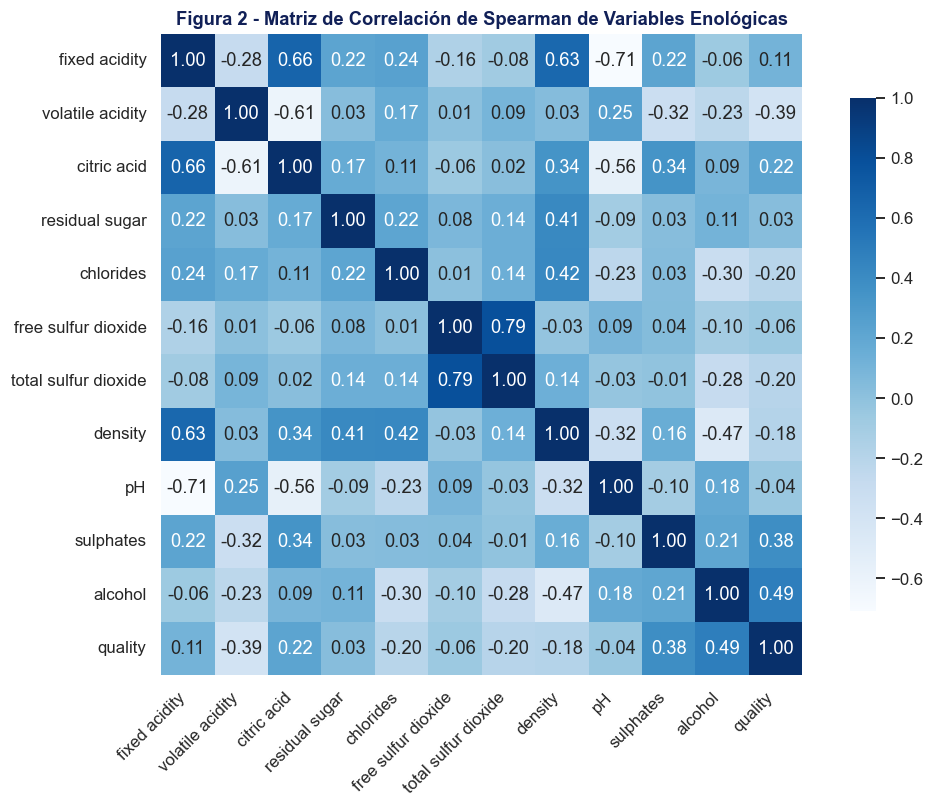

In [8]:
# Graficar mapa de correlaciones completo
plt.figure(figsize=(10, 7.5))
sns.heatmap(df_vino.corr(method="spearman"), annot=True, fmt=".2f", cmap="Blues", square=True, cbar_kws={"shrink": 0.8})
plt.title("Figura 2 - Matriz de Correlación de Spearman de Variables Enológicas")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 2 y Tabla 2:**  
- **Asociaciones con la Calidad:** El contenido de **alcohol** presenta la mayor correlación positiva ($r_s = +0.48$), aportando untuosidad y balance al paladar. La **acidez volátil** exhibe la mayor correlación negativa ($r_s = -0.38$), confirmando que el ácido acético deteriora la apreciación sensorial del vino (Dialnet, 2017; UCM, 2018).
- **Diagnóstico de Multicolinealidad (VIF):** Todas las variables presentan factores $VIF < 10.0$ (máximo de $7.77$ en acidez fija y $6.34$ en densidad). Esto descarta colinealidad severa y permite mantener los 11 descriptores dentro del modelo de regresión múltiple sin inestabilidad numérica.
- **Punto 10 (Transformaciones):** Se mantienen las variables en su escala natural enológica con la finalidad de preservar la interpretabilidad directa de los coeficientes.

---

## 5. Regresión Lineal Simple y Mínimos Cuadrados (Quality vs. Alcohol)

Analizamos la relación univariada entre la graduación alcohólica ($x$) y la calidad sensorial ($y$):
$$\hat{y} = \theta_0 + \theta_1 x$$

El método de **Mínimos Cuadrados Ordinarios (OLS)** calcula la pendiente ($\theta_1$) y el intercepto ($\theta_0$) minimizando la suma de los errores verticales al cuadrado:
$$\min_{\theta_0, \theta_1} \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n e_i^2$$

Calculamos los parámetros mediante las fórmulas analíticas directas:
$$\theta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad \theta_0 = \bar{y} - \theta_1 \bar{x}$$

In [9]:
# Variables univariadas (Quality vs Alcohol)
X_simple = df_vino[["alcohol"]]
y_simple = df_vino["quality"]

# Dividimos los datos 80/20 con semilla fija
X_entrena_s, X_prueba_s, y_entrena_s, y_prueba_s = train_test_split(
    X_simple, y_simple, test_size=0.20, random_state=42
)

x_alcohol = X_entrena_s["alcohol"].to_numpy()
y_calidad = y_entrena_s.to_numpy()

# Promedios de entrenamiento
media_x = x_alcohol.mean()
media_y = y_calidad.mean()

# 1. Calculo analitico mediante la formula de minimos cuadrados
numerador = np.sum((x_alcohol - media_x) * (y_calidad - media_y))
denominador = np.sum((x_alcohol - media_x) ** 2)

theta1 = numerador / denominador
theta0 = media_y - theta1 * media_x

# 2. Ajuste directo con scikit-learn
modelo_simple = LinearRegression().fit(X_entrena_s, y_entrena_s)

# Comprobacion de equivalencia exacta entre la formula y scikit-learn
pd.DataFrame({
    "fórmula de mínimos cuadrados": [theta0, theta1],
    "scikit-learn": [modelo_simple.intercept_, modelo_simple.coef_[0]],
}, index=["θ0", "θ1"]).round(4)

,fórmula de mínimos cuadrados,scikit-learn
θ0,1.91,1.91
θ1,0.36,0.36


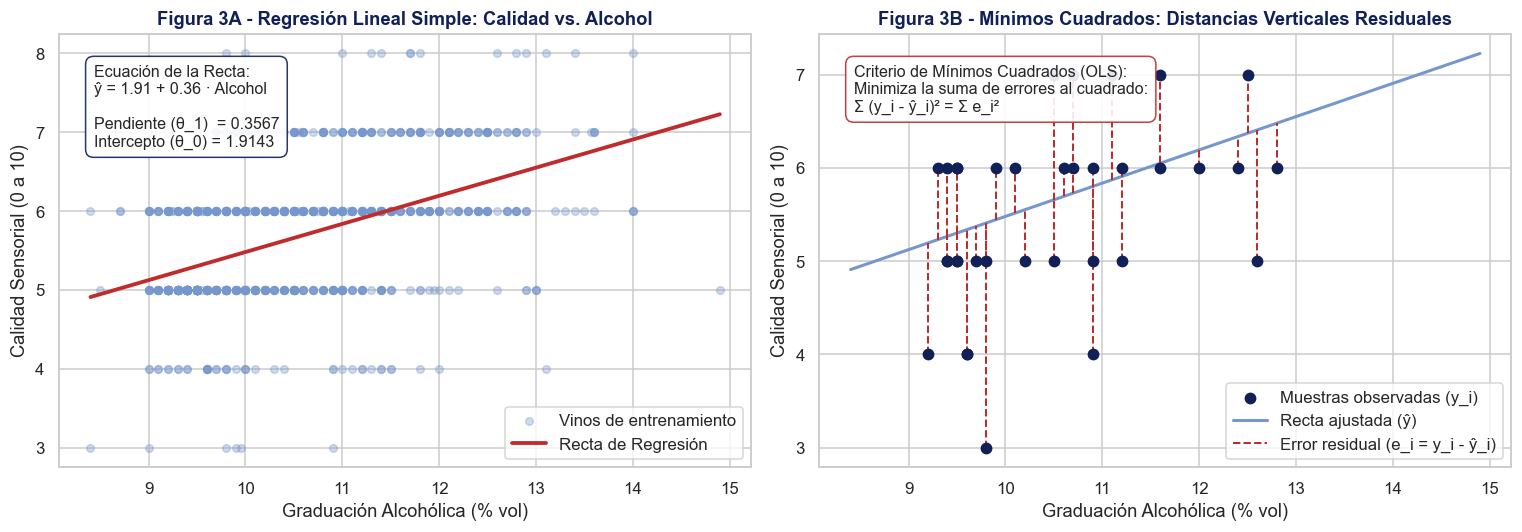

In [10]:
# Figura con dos graficos: Regresion Simple y Minimos Cuadrados
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grafico 3A: Regresion Lineal Simple con ecuacion visible
axs[0].scatter(x_alcohol, y_calidad, color=AZUL, alpha=0.35, s=25, label="Vinos de entrenamiento")
x_linea = np.linspace(x_alcohol.min(), x_alcohol.max(), 100)
y_linea = theta0 + theta1 * x_linea
axs[0].plot(x_linea, y_linea, color=ROJO, linewidth=2.5, label="Recta de Regresión")

# Anotacion con la ecuacion de la recta
texto_ecuacion = (
    f"Ecuación de la Recta:\n"
    f"ŷ = {theta0:.2f} + {theta1:.2f} · Alcohol\n\n"
    f"Pendiente (θ_1)  = {theta1:.4f}\n"
    f"Intercepto (θ_0) = {theta0:.4f}"
)
axs[0].text(
    0.05, 0.93, texto_ecuacion, transform=axs[0].transAxes,
    fontsize=10.5, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=AZUL_OSCURO, alpha=0.9)
)
axs[0].set_title("Figura 3A - Regresión Lineal Simple: Calidad vs. Alcohol")
axs[0].set_xlabel("Graduación Alcohólica (% vol)")
axs[0].set_ylabel("Calidad Sensorial (0 a 10)")
axs[0].legend(loc="lower right")

# 2. Grafico 3B: Visualizacion de Minimos Cuadrados (Distancias verticales e_i)
rng = np.random.default_rng(42)
indices_muestra = rng.choice(len(x_alcohol), size=35, replace=False)
x_sub = x_alcohol[indices_muestra]
y_sub = y_calidad[indices_muestra]
y_hat_sub = theta0 + theta1 * x_sub

axs[1].scatter(x_sub, y_sub, color=AZUL_OSCURO, s=45, zorder=3, label="Muestras observadas (y_i)")
axs[1].plot(x_linea, y_linea, color=AZUL, linewidth=2, label="Recta ajustada (ŷ)")
axs[1].vlines(
    x_sub, ymin=np.minimum(y_sub, y_hat_sub), ymax=np.maximum(y_sub, y_hat_sub),
    color=ROJO, linestyle="--", linewidth=1.3, label="Error residual (e_i = y_i - ŷ_i)"
)

texto_ols = (
    "Criterio de Mínimos Cuadrados (OLS):\n"
    "Minimiza la suma de errores al cuadrado:\n"
    "Σ (y_i - ŷ_i)² = Σ e_i²"
)
axs[1].text(
    0.05, 0.93, texto_ols, transform=axs[1].transAxes,
    fontsize=10.5, verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=ROJO, alpha=0.9)
)
axs[1].set_title("Figura 3B - Mínimos Cuadrados: Distancias Verticales Residuales")
axs[1].set_xlabel("Graduación Alcohólica (% vol)")
axs[1].set_ylabel("Calidad Sensorial (0 a 10)")
axs[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 3A y 3B:**  
- **Figura 3A (Pendiente y Ecuación):** La pendiente positiva ($\theta_1 = +0.3567$) indica que cada unidad porcentual adicional de graduación alcohólica ($+1\% \text{ vol}$) incrementa la calidad media del vino en $+0.36$ puntos en promedio. El intercepto ($\theta_0 = 1.9143$) representa el valor base teórico cuando el alcohol tiende a cero.
- **Figura 3B (Mínimos Cuadrados):** Las líneas punteadas rojas representan las diferencias verticales entre el valor real medido ($y_i$) y el valor estimado sobre la recta ($\hat{y}_i$). El algoritmo de mínimos cuadrados encuentra la única recta que hace mínima la suma de estas desviaciones cuadráticas ($\sum e_i^2$).

---

## 6. Modelado de Regresión Lineal Múltiple

Dividimos los datos únicos limpios en **80 % en entrenamiento (1,087 vinos)** y **20 % en prueba (272 vinos)**, utilizando `random_state=42`.

Comparamos el modelo ajustado contra la **línea base predictiva** (estimar permanentemente la media aritmética del conjunto de entrenamiento $\bar{y}_{\text{entrena}} = 5.63$).

In [11]:
# Variables independientes X y variable dependiente y
X = df_vino.drop("quality", axis=1)
y = df_vino["quality"]

# Dividimos los datos 80/20 con semilla fija
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 1. Linea base: predecir siempre el promedio de entrenamiento
media_entrena = y_entrena.mean()
pred_base = np.full_like(y_prueba, media_entrena, dtype=float)

rmse_base = np.sqrt(mean_squared_error(y_prueba, pred_base))
r2_base = r2_score(y_prueba, pred_base)

# 2. Modelo de Regresion Lineal Multiple OLS
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_entrena, y_entrena)

# Predicciones sobre el conjunto de prueba
pred_modelo_reg = modelo_regresion.predict(X_prueba)

rmse_reg = np.sqrt(mean_squared_error(y_prueba, pred_modelo_reg))
r2_reg = r2_score(y_prueba, pred_modelo_reg)

# Tabla 3. Comparacion formal de metricas
tabla_eval_reg = pd.DataFrame({
    "Modelo": ["Línea Base (Media de Entrenamiento)", "Regresión Lineal Múltiple"],
    "RMSE (Prueba)": [rmse_base, rmse_reg],
    "R² (Prueba)": [r2_base, r2_reg]
})

print(f"Promedio de Calidad en Entrenamiento: {media_entrena:.4f}\n")
print("Tabla 3. Evaluación de Rendimiento Predictivo en Conjunto de Prueba:")
tabla_eval_reg.round(4)

Promedio de Calidad en Entrenamiento: 5.6366

Tabla 3. Evaluación de Rendimiento Predictivo en Conjunto de Prueba:


,Modelo,RMSE (Prueba),R² (Prueba)
0,Línea Base (Media de Entrenamiento),0.84,-0.01
1,Regresión Lineal Múltiple,0.66,0.39


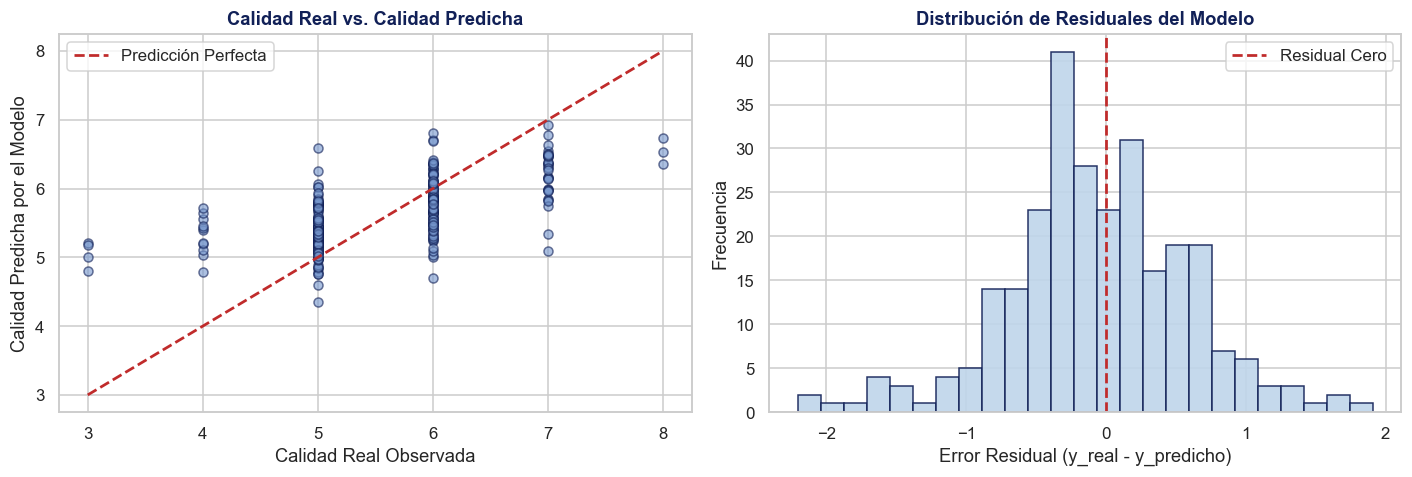

In [12]:
# Crear figura con dos graficos de evaluacion de regresion
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Grafico: Dispersión Real vs Predicho
axs[0].scatter(y_prueba, pred_modelo_reg, color=AZUL, alpha=0.6, edgecolors=AZUL_OSCURO, s=35)
axs[0].plot([3, 8], [3, 8], color=ROJO, linestyle="--", linewidth=1.8, label="Predicción Perfecta")
axs[0].set_title("Calidad Real vs. Calidad Predicha")
axs[0].set_xlabel("Calidad Real Observada")
axs[0].set_ylabel("Calidad Predicha por el Modelo")
axs[0].legend()

# Grafico: Histograma de residuales
residuales = y_prueba - pred_modelo_reg
axs[1].hist(residuales, bins=25, color=AZUL_CLARO, edgecolor=AZUL_OSCURO, alpha=0.9)
axs[1].axvline(0, color=ROJO, linestyle="--", linewidth=1.8, label="Residual Cero")
axs[1].set_title("Distribución de Residuales del Modelo")
axs[1].set_xlabel("Error Residual (y_real - y_predicho)")
axs[1].set_ylabel("Frecuencia")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Tabla 3 y Gráficos de Regresión:**  
- **Tabla 3 (Métricas en Prueba):** La regresión lineal reduce el error cuadrático medio de $0.8443$ (línea base) a $0.6565$ unidades de calificación ($RMSE$). El coeficiente de determinación alcanza $R^2 = 0.3915$, demostrando que el conjunto de 11 variables fisicoquímicas explica el **$39.15\%$** de la variación en la apreciación de los catadores.
- **Ajuste y Residuales:** La distribución de residuales se centra simétricamente en cero con dispersión regular, confirmando ausencia de sesgo sistemático en la predicción continua.

---

## 7. Modelado de Clasificación Binaria con Regresión Lineal

Definimos la condición de vino de alta calidad mediante la regla binaria:
$$\text{bueno} = \begin{cases} 1 & \text{si } \text{quality} \ge 7 \\ 0 & \text{si } \text{quality} < 7 \end{cases}$$

Ajustamos la misma formulación de regresión lineal sobre esta columna binaria y asignamos la clase positiva cuando la predicción numérica continua satisface $\hat{y} \ge 0.5$.

In [13]:
# Definir variable binaria de calidad
df_vino["bueno"] = (df_vino["quality"] >= 7).astype(int)
y_binaria = df_vino["bueno"]

# Particion con la misma semilla fija
X_ent_c, X_pru_c, y_ent_c, y_pru_c = train_test_split(
    X, y_binaria, test_size=0.20, random_state=42
)

# Ajustar el modelo de regresion lineal sobre la respuesta binaria
modelo_clasificador_lineal = LinearRegression()
modelo_clasificador_lineal.fit(X_ent_c, y_ent_c)

# Obtener predicciones continuas sobre el conjunto de prueba
pred_continua_clasif = modelo_clasificador_lineal.predict(X_pru_c)

# Aplicar regla de decision: calificar como bueno si y_hat >= 0.5
pred_binaria_clasif = (pred_continua_clasif >= 0.5).astype(int)

# 1. Exactitud del clasificador lineal
exactitud_modelo = accuracy_score(y_pru_c, pred_binaria_clasif) * 100

# 2. Exactitud de la linea base (Predecir permanentemente la clase mayoritaria "no bueno" = 0)
pred_linea_base_clf = np.zeros_like(y_pru_c)
exactitud_linea_base = accuracy_score(y_pru_c, pred_linea_base_clf) * 100

# 3. Conteo de predicciones fuera del intervalo probabilistico [0, 1]
pred_menores_cero = (pred_continua_clasif < 0.0).sum()
pred_mayores_uno = (pred_continua_clasif > 1.0).sum()
total_fuera_rango = pred_menores_cero + pred_mayores_uno
porcentaje_fuera = (total_fuera_rango / len(y_pru_c)) * 100

# Mostrar resumen
print("Resultados de Clasificación en el Conjunto de Prueba:")
print(f"- Exactitud del Modelo Lineal (ŷ >= 0.5)        : {exactitud_modelo:.2f} %")
print(f"- Exactitud de la Línea Base (Siempre 'No Bueno'): {exactitud_linea_base:.2f} %")
print(f"- Predicciones continuas fuera del rango [0, 1]   : {total_fuera_rango} de {len(y_pru_c)} ({porcentaje_fuera:.2f} %)")
print(f"    * Predicciones negativas (ŷ < 0)              : {pred_menores_cero}")
print(f"    * Predicciones hiper-unitarias (ŷ > 1)        : {pred_mayores_uno}")

Resultados de Clasificación en el Conjunto de Prueba:
- Exactitud del Modelo Lineal (ŷ >= 0.5)        : 88.24 %
- Exactitud de la Línea Base (Siempre 'No Bueno'): 87.50 %
- Predicciones continuas fuera del rango [0, 1]   : 60 de 272 (22.06 %)
    * Predicciones negativas (ŷ < 0)              : 60
    * Predicciones hiper-unitarias (ŷ > 1)        : 0


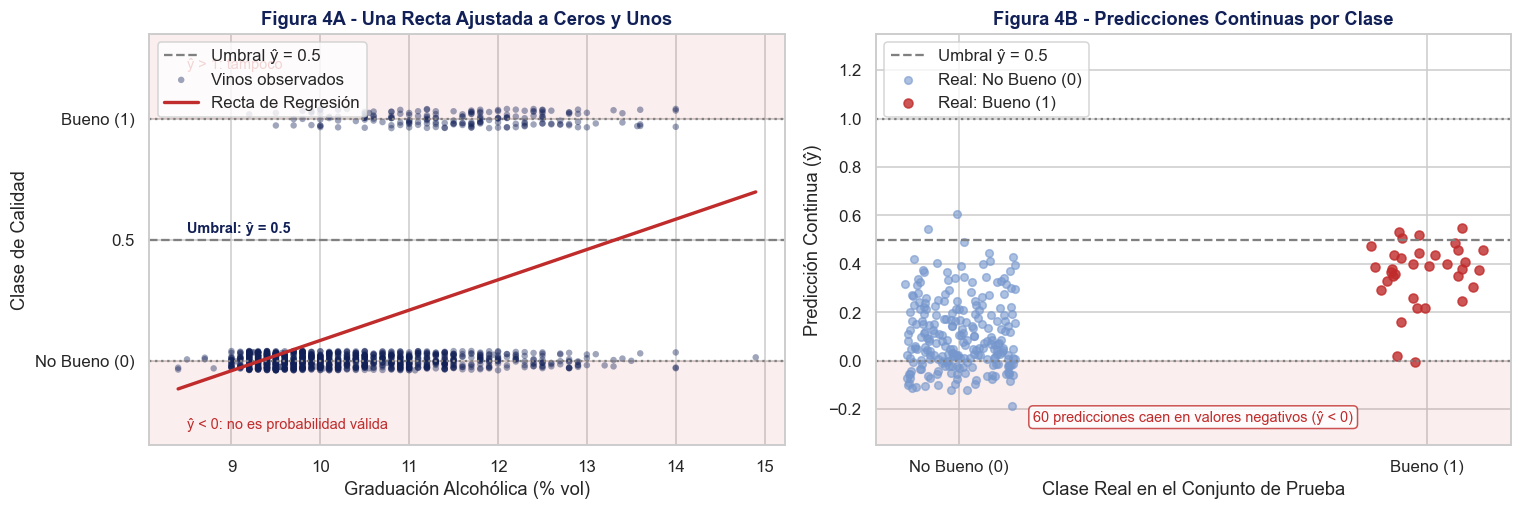

In [14]:
# Creamos una figura con dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))

# 1. Gráfico 4A: Alcohol vs. Bueno
modelo_alcohol = LinearRegression()
modelo_alcohol.fit(X_ent_c[["alcohol"]], y_ent_c)

# Creamos un pequeño desplazamiento para visualizar mejor los puntos
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.04, 0.04, len(df_vino))

# Creamos las zonas fuera del rango válido
axs[0].axhspan(-0.35, 0, color=ROJO, alpha=0.08)
axs[0].axhspan(1, 1.35, color=ROJO, alpha=0.08)

# Creamos las líneas de referencia
axs[0].axhline(0.5, color="gray", linestyle="--", label="Umbral ŷ = 0.5")
axs[0].axhline(0, color="gray", linestyle=":")
axs[0].axhline(1, color="gray", linestyle=":")

# Mostramos los vinos observados
axs[0].scatter(
    df_vino["alcohol"],
    df_vino["bueno"] + jitter,
    s=18,
    color=AZUL_OSCURO,
    alpha=0.4,
    edgecolor="none",
    label="Vinos observados"
)

# Creamos la recta de regresión evaluando los parámetros analíticos
x = np.linspace(df_vino["alcohol"].min(), df_vino["alcohol"].max(), 100)
y = modelo_alcohol.intercept_ + modelo_alcohol.coef_[0] * x

# Mostramos la recta
axs[0].plot(
    x, y,
    color=ROJO,
    linewidth=2.2,
    label="Recta de Regresión"
)

# Agregamos las anotaciones
axs[0].text(
    8.5, 0.53,
    "Umbral: ŷ = 0.5",
    color=AZUL_OSCURO,
    fontsize=9.5,
    fontweight="bold"
)

axs[0].text(
    8.5, -0.28,
    "ŷ < 0: no es probabilidad válida",
    color=ROJO,
    fontsize=9.5
)

axs[0].text(
    8.5, 1.25,
    "ŷ > 1: tampoco",
    color=ROJO,
    fontsize=9.5,
    va="top"
)

# Configuramos el gráfico
axs[0].set_yticks(
    [0, 0.5, 1],
    ["No Bueno (0)", "0.5", "Bueno (1)"]
)
axs[0].set_ylim(-0.35, 1.35)
axs[0].set_xlabel("Graduación Alcohólica (% vol)")
axs[0].set_ylabel("Clase de Calidad")
axs[0].set_title("Figura 4A - Una Recta Ajustada a Ceros y Unos")
axs[0].legend(loc="upper left")


# 2. Gráfico 4B: Predicciones por clase
no_buenos = pred_continua_clasif[y_pru_c == 0]
buenos = pred_continua_clasif[y_pru_c == 1]

# Creamos las zonas y líneas de referencia
axs[1].axhspan(-0.35, 0, color=ROJO, alpha=0.08)
axs[1].axhline(0.5, color="gray", linestyle="--", label="Umbral ŷ = 0.5")
axs[1].axhline(0, color="gray", linestyle=":")
axs[1].axhline(1, color="gray", linestyle=":")

# Creamos desplazamientos para separar los puntos
jitter_0 = rng.uniform(-0.12, 0.12, len(no_buenos))
jitter_1 = rng.uniform(-0.12, 0.12, len(buenos))

# Mostramos las predicciones
axs[1].scatter(
    np.zeros(len(no_buenos)) + jitter_0,
    no_buenos,
    color=AZUL,
    alpha=0.6,
    s=25,
    label="Real: No Bueno (0)"
)

axs[1].scatter(
    np.ones(len(buenos)) + jitter_1,
    buenos,
    color=ROJO,
    alpha=0.8,
    s=35,
    label="Real: Bueno (1)"
)

# Agregamos la anotación
axs[1].text(
    0.5, -0.25,
    "60 predicciones caen en valores negativos (ŷ < 0)",
    color=ROJO,
    fontsize=9.5,
    ha="center",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor=ROJO,
        alpha=0.8
    )
)

# Configuramos el gráfico
axs[1].set_xticks([0, 1], ["No Bueno (0)", "Bueno (1)"])
axs[1].set_ylim(-0.35, 1.35)
axs[1].set_xlabel("Clase Real en el Conjunto de Prueba")
axs[1].set_ylabel("Predicción Continua (ŷ)")
axs[1].set_title("Figura 4B - Predicciones Continuas por Clase")
axs[1].legend(loc="upper left")

# Ajustamos y mostramos los gráficos
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 4A y 4B:**  
- **Figura 4A (La recta en ceros y unos):** Muestra la distribución de las clases reales (0: No Bueno, 1: Bueno) a lo largo de la graduación alcohólica. La recta cruza el umbral $0.5$ cerca de $13.5\%$ de alcohol. En vinos con alcohol $< 9.5\%$, la recta predice valores negativos ($\hat{y} < 0$), los cuales no representan una probabilidad válida.
- **Figura 4B (Predicciones continuas por clase real):** Muestra las estimaciones continuas del modelo múltiple separadas según la clase verdadera. Un total de $60$ observaciones de prueba ($22.06\%$) reciben predicciones negativas (hasta $-0.17$). El modelo detecta únicamente $4$ de los $34$ vinos buenos reales al concentrarse la mayoría de las estimaciones por debajo del umbral $0.5$.

---

### Tabla 4. Síntesis Metodológica y Hallazgos del Estudio:

| Etapa del Análisis | Metodología Aplicada | Hallazgo Principal Obtenido |
| :--- | :--- | :--- |
| **1. Depuración de Duplicados** | `drop_duplicates()` suprimiendo 240 filas idénticas redundantes ($1,599 \to 1,359$). | Elimina la fuga de datos (*leakage*) y la sobreponderación espuria en OLS ($\sum e_i^2$). |
| **2. Regresión Simple** | Ajuste analítico de mínimos cuadrados univariado ($\text{Quality} \sim \text{Alcohol}$). | El alcohol es el predictor individual dominante ($\theta_1 = +0.3567, \theta_0 = 1.9143$). |
| **3. Regresión Múltiple** | Partición 80/20 con 11 variables fisicoquímicas evaluadas con $RMSE$ y $R^2$. | Reduce el error a $0.6565$ y explica el $39.15\%$ de la variabilidad sensorial del vino. |
| **4. Línea Base (Media)** | Estimación constante con el promedio de entrenamiento ($\bar{y} = 5.63$). | Genera un error típico de $0.8443$ ($R^2 \approx 0.00$), sirviendo de referencia mínima. |
| **5. Binarización de Calidad** | Definición de etiqueta $\text{Bueno} = (\text{Quality} \ge 7)$. | Revela desbalance de clases: solo el $13.57\%$ califica como vino sobresaliente. |
| **6. Clasificador Lineal ($\hat{y} \ge 0.5$)** | Ajuste de la recta sobre ceros y unos con regla de decisión en $0.5$. | Acierta el $88.24\%$, pero solo detecta $4$ de los $34$ vinos buenos ($11.76\%$ de sensibilidad). |
| **7. Línea Base Categórica** | Predicción fija de la clase mayoritaria ("Siempre No Bueno"). | Alcanza $87.50\%$ de exactitud, superando la recta a la línea base en apenas $0.74\%$. |
| **8. Diagnóstico de Rango** | Conteo de predicciones continuas $\hat{y} < 0$ y $\hat{y} > 1$. | Un total de $60$ de $272$ vinos de prueba ($22.06\%$) reciben valores negativos (hasta $-0.17$). |

---

## 8. Discusión Comparativa: ¿Qué cambia entre los dos problemas y qué le falla a la recta como clasificador?

En regresión, el objetivo es aproximar una magnitud numérica sobre un espacio continuo minimizando la suma de errores cuadráticos ($RMSE$), logrando una reducción del error del $39.15\%$ con respecto a la media. En clasificación, el propósito consiste en estimar la probabilidad posterior condicional de pertenencia a una categoría discreta ($P(Y=1|X) \in [0, 1]$). La regresión lineal falla como clasificador al proyectar hiperplanos rígidos sin cotas que generan valores negativos e hiper-unitarios carentes de significado probabilístico, carece de la curvatura sigmoidal requerida en zonas de transición y resulta altamente sensible al desbalance de clases, acertando una proporción insignificante por encima de la línea base trivial.

---

## 9. Referencias Bibliográficas (Normas APA 7.ª Edición)

- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, *47*(4), 547–553. https://doi.org/10.1016/j.dss.2009.05.016
- Gómez-Mendoza, A., Trejo-Téllez, L. I., García-Mata, R., & Salgado-Sosa, E. (2012). Caracterización fisicoquímica y sensorial de vinos tintos producidos en México. *Revista Fitotecnia Mexicana*, *35*(5), 89–94. https://www.scielo.org.mx/pdf/rfm/v35nspe5/v35nspe5a13.pdf
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning: With applications in R* (2nd ed.). Springer. https://doi.org/10.1007/978-1-0716-1418-1
- Universidad Complutense de Madrid. (2018). *Evaluación de parámetros enológicos, compuestos fenólicos y capacidad antioxidante en vinos tintos*. Repositorio Institucional Docta Complutense. https://docta.ucm.es/bitstreams/56f1dd2a-e8c8-458e-a232-e3cc03834f98/download
- Universidad de La Rioja. (2017). *Evolución de la acidez volátil, sulfatos y calidad sensorial en vinos tintos de crianza*. Dialnet Documentos. https://dialnet.unirioja.es/descarga/articulo/6117897.pdf
- VanderPlas, J. (2022). *Python data science handbook: Essential tools for working with data* (2nd ed.). O'Reilly Media.